# Shearing-box model
In this notebook we calculate the solutions for Ogilvie & Latter (2013)'s shearing-box model.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, cumulative_trapezoid

In [13]:
## Some helper functions that will be useful.
def m1_amp(tau, y):
    a = np.trapz(y * np.cos(tau), tau) / np.pi
    b = np.trapz(y * np.sin(tau), tau) / np.pi
    return np.sqrt(a*a + b*b)


def calculate_Q1(tau, u, v, g, alpha, psi, q=1.5):
    integrand = -u * v / g + alpha * (-q + psi * np.cos(tau) * v)
    return np.trapz(integrand, tau) / (tau[-1] - tau[0])


def calculate_Q4psi(tau, u, w, g, alpha, psi):
    integrand = np.exp(1j * tau) * (
        u / g * (1.0 + 1j * w)
        - 1j * alpha * (psi * np.sin(tau) + psi * np.cos(tau) * w + u)
    )
    Q4psi = np.trapz(integrand, tau) / (tau[-1] - tau[0])
    return Q4psi

## Full equations

Starting with the original equations from Ogilvie & Latter (2013) after droping $\alpha_b$ and $\epsilon$:
\begin{align}
\partial_\tau u
&+ \left(w + |\psi|\cos\tau\, u\right)u - 2v
= |\psi|\cos\tau\, g \notag\\
&\quad - \frac{\alpha}{3}\,|\psi|\cos\tau\, g
\left(w+|\psi|\cos\tau\,u\right) \notag\\
&\quad - \alpha g\left[|\psi|\sin\tau
+\left(1+|\psi|^2\cos^2\tau\right)u\right],
\\
\partial_\tau v
&+ \left(w+|\psi|\cos\tau\,u\right)v + \frac{1}{2}u \notag\\
&= -\alpha g\left[-\frac{3}{2}|\psi|\cos\tau
+\left(1+|\psi|^2\cos^2\tau\right)v\right],
\\
\partial_\tau w
&+ \left(w+|\psi|\cos\tau\,u\right)w
+|\psi|\sin\tau\,u
= g-1 \notag\\
&\quad - \frac{\alpha}{3}\, g
\left(w+|\psi|\cos\tau\,u\right) \notag\\
&\quad -\alpha g\left[|\psi|^2\sin\tau\cos\tau
+\left(1+|\psi|^2\cos^2\tau\right)w\right],
\\
\partial_\tau f
&= -\left(w+|\psi|\cos\tau\,u\right),
\\
\partial_\tau g
&= -2\left(w+|\psi|\cos\tau\,u\right)g .
\end{align}
Now below is the code for solving it.

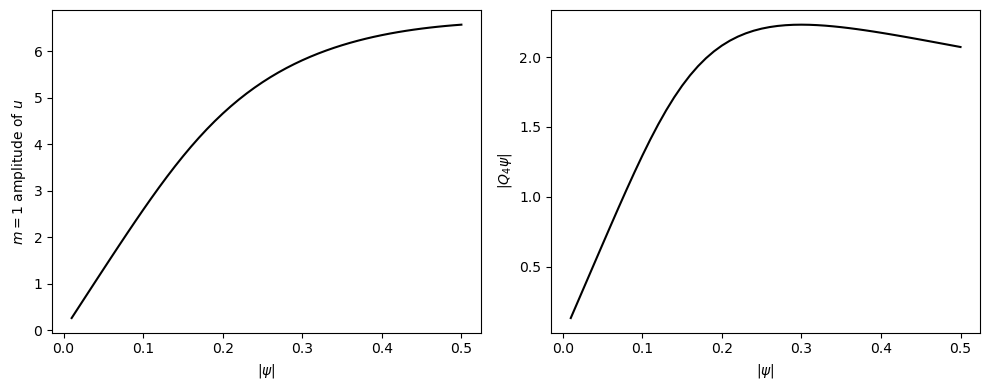

In [16]:

def rhs(tau, y, alpha, psi):
    """
    Full nonlinear Ogilvie-Latter ODEs with alpha_b=0, q=3/2, epsilon=0.

    y = [u, v, w, g]
    """
    u, v, w, g = y

    c = np.cos(tau)
    s = np.sin(tau)

    A = w + psi * c * u

    du = (
        -A * u
        + 2.0 * v
        + psi * c * g
        - (alpha / 3.0) * psi * c * g * A
        - alpha * g * (psi * s + (1.0 + psi**2 * c**2) * u)
    )

    dv = (
        -A * v
        - 0.5 * u
        - alpha * g * (-1.5 * psi * c + (1.0 + psi**2 * c**2) * v)
    )

    dw = (
        -A * w
        - psi * s * u
        + g
        - 1.0
        - (alpha / 3.0) * g * A
        - alpha * g * (psi**2 * s * c + (1.0 + psi**2 * c**2) * w)
    )

    dg = -2.0 * A * g

    return np.vstack([du, dv, dw, dg])


def periodic_bc(ya, yb):
    return ya - yb


def initial_guess(tau, alpha, psi):
    """
    Weak-warp initial guess.
    """
    y = np.zeros((4, tau.size))
    y[0] = psi * np.cos(tau)          # u
    y[1] = -0.5 * psi * np.sin(tau)   # v
    y[2] = 0.0                        # w
    y[3] = 1.0                        # g
    return y


def solve_one(alpha, psi, tau, y_guess=None, tol=1e-8):
    if y_guess is None:
        y_guess = initial_guess(tau, alpha, psi)

    sol = solve_bvp(
        lambda t, y: rhs(t, y, alpha, psi),
        periodic_bc,
        tau,
        y_guess,
        tol=tol,
        max_nodes=50000,
        verbose=0,
    )

    if not sol.success:
        print(f"Failed at psi={psi}: {sol.message}")

    return sol


def solve_continuation(alpha=0.019, psi_values=None, n_grid=600, tol=1e-8):
    if psi_values is None:
        psi_values = np.linspace(0.01, 0.5, 50)

    tau = np.linspace(0.0, 2.0 * np.pi, n_grid)
    sols = []

    y_guess = None

    for psi in psi_values:
        sol = solve_one(alpha, psi, tau, y_guess=y_guess, tol=tol)
        sols.append(sol)

        # continuation: use previous solution as next initial guess
        y_guess = sol.sol(tau)

    return tau, sols


# Example
alpha = 0.019
psi_values = np.linspace(0.01, 0.5, 50)

tau_mesh, sols = solve_continuation(alpha=alpha, psi_values=psi_values)

tau_plot = np.linspace(0.0, 2.0 * np.pi, 2000, endpoint=False)

U1_list = []
gmin_list = []
Q4psi_list = []

for psi, sol in zip(psi_values, sols):
    u, v, w, g = sol.sol(tau_plot)

    U1_list.append(m1_amp(tau_plot, u))
    gmin_list.append(np.min(g))
    Q4psi_list.append(calculate_Q4psi(tau_plot, u, w, g, alpha, psi))


fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

axs[0].plot(psi_values, U1_list, "k-")
axs[0].set_xlabel(r"$|\psi|$")
axs[0].set_ylabel(r"$m=1$ amplitude of $u$")

axs[1].plot(psi_values, np.abs(Q4psi_list), "k-")
axs[1].set_xlabel(r"$|\psi|$")
axs[1].set_ylabel(r"$|Q_4\psi|$")

plt.tight_layout()
plt.show()    


## Transformed Equations

We then introduce the transformed variables
\begin{align}
(U,V,W)=(u,v,w)H,\qquad H=g^{-1/2}.
\end{align}
This will lead to a set of equations in different variables
\begin{align}
\partial_\tau U - 2V
&=
\frac{|\psi|\cos\tau}{H}
-\frac{\alpha}{3}
\frac{|\psi|\cos\tau}{H^2}
\left(W+|\psi|\cos\tau\,U\right) 
-\alpha\left[
\frac{|\psi|\sin\tau}{H}
+\frac{\left(1+|\psi|^2\cos^2\tau\right)U}{H^2}
\right],
\\
\partial_\tau V + \frac{1}{2}U
&=
\frac{3}{2}\alpha
\frac{|\psi|\cos\tau}{H}
-\alpha
\frac{\left(1+|\psi|^2\cos^2\tau\right)V}{H^2},
\\
\partial_\tau W + |\psi|\sin\tau\,U
&=
\frac{1}{H}-H
-\frac{\alpha}{3}
\frac{W+|\psi|\cos\tau\,U}{H^2}
-\alpha\left[
\frac{|\psi|^2\sin\tau\cos\tau}{H}
+\frac{\left(1+|\psi|^2\cos^2\tau\right)W}{H^2}
\right],
\\
\partial_\tau H
&=
W+|\psi|\cos\tau\,U .
\end{align}
We can also solve these equations, and the same result as solving the equations above.

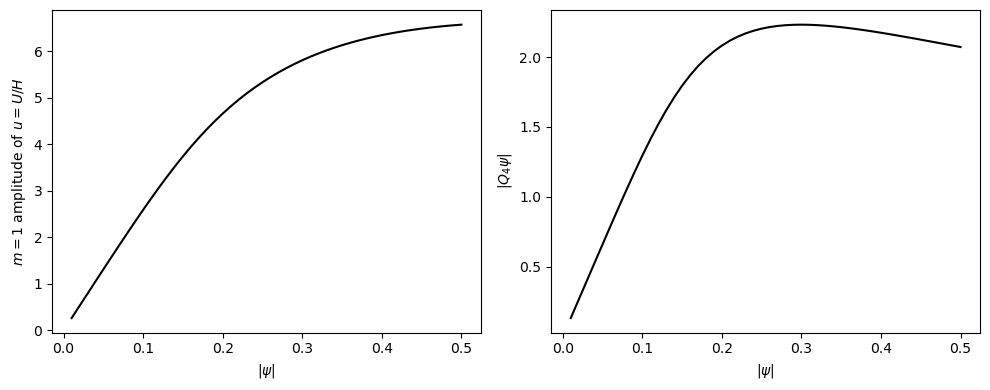

In [19]:
def rhs_transformed(tau, y, alpha, psi):
    """
    Transformed Ogilvie-Latter equations.

    y = [U, V, W, H]
    """
    U, V, W, H = y

    c = np.cos(tau)
    s = np.sin(tau)

    dU = (
        2.0 * V
        + psi * c / H
        - (alpha / 3.0) * psi * c * (W + psi * c * U) / H**2
        - alpha * (
            psi * s / H
            + (1.0 + psi**2 * c**2) * U / H**2
        )
    )

    dV = (
        -0.5 * U
        + 1.5 * alpha * psi * c / H
        - alpha * (1.0 + psi**2 * c**2) * V / H**2
    )

    dW = (
        -psi * s * U
        + 1.0 / H
        - H
        - (alpha / 3.0) * (W + psi * c * U) / H**2
        - alpha * (
            psi**2 * s * c / H
            + (1.0 + psi**2 * c**2) * W / H**2
        )
    )

    dH = W + psi * c * U

    return np.vstack([dU, dV, dW, dH])


def periodic_bc(ya, yb):
    return ya - yb


def initial_guess_transformed(tau, alpha, psi):
    y = np.zeros((4, tau.size))
    y[0] = psi * np.cos(tau)          # U
    y[1] = -0.5 * psi * np.sin(tau)   # V
    y[2] = 0.0                        # W
    y[3] = 1.0                        # H
    return y


def solve_one_transformed(alpha, psi, tau, y_guess=None, tol=1e-8):
    if y_guess is None:
        y_guess = initial_guess_transformed(tau, alpha, psi)

    sol = solve_bvp(
        lambda t, y: rhs_transformed(t, y, alpha, psi),
        periodic_bc,
        tau,
        y_guess,
        tol=tol,
        max_nodes=50000,
        verbose=0,
    )

    if not sol.success:
        print(f"Failed at psi={psi}: {sol.message}")

    return sol


def solve_continuation_transformed(alpha=0.019, psi_values=None, n_grid=600, tol=1e-8):
    if psi_values is None:
        psi_values = np.linspace(0.01, 0.5, 50)

    tau = np.linspace(0.0, 2.0 * np.pi, n_grid)
    sols = []

    y_guess = None

    for psi in psi_values:
        sol = solve_one_transformed(alpha, psi, tau, y_guess=y_guess, tol=tol)
        sols.append(sol)

        # continuation: use previous solution as next initial guess
        y_guess = sol.sol(tau)

    return tau, sols


def m1_amp(tau, y):
    a = np.trapz(y * np.cos(tau), tau) / np.pi
    b = np.trapz(y * np.sin(tau), tau) / np.pi
    return np.sqrt(a*a + b*b)


def calculate_Q4psi(tau, U, W, H, alpha, psi):
    """
    Calculate Q4*|psi| using original variables:
    u = U/H, w = W/H, g = 1/H^2.
    """
    u = U / H
    w = W / H
    g = 1.0 / H**2

    integrand = np.exp(1j * tau) * (
        u / g * (1.0 + 1j * w)
        - 1j * alpha * (psi * np.sin(tau) + psi * np.cos(tau) * w + u)
    )

    return np.trapz(integrand, tau) / (tau[-1] - tau[0])


# Example
alpha = 0.019
psi_values = np.linspace(0.01, 0.5, 50)

tau_mesh, sols = solve_continuation_transformed(
    alpha=alpha,
    psi_values=psi_values,
    n_grid=600,
    tol=1e-8,
)

tau_plot = np.linspace(0.0, 2.0 * np.pi, 2000, endpoint=False)

U1_list = []
Hmin_list = []
Q4psi_list = []

for psi, sol in zip(psi_values, sols):
    U, V, W, H = sol.sol(tau_plot)

    # Recover original variables if needed
    u = U / H
    v = V / H
    w = W / H
    g = 1.0 / H**2

    U1_list.append(m1_amp(tau_plot, u))
    Hmin_list.append(np.min(H))
    Q4psi_list.append(calculate_Q4psi(tau_plot, U, W, H, alpha, psi))


Q4psi_list = np.array(Q4psi_list)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

axs[0].plot(psi_values, U1_list, "k-")
axs[0].set_xlabel(r"$|\psi|$")
axs[0].set_ylabel(r"$m=1$ amplitude of $u=U/H$")

axs[1].plot(psi_values, np.abs(Q4psi_list), "k-")
axs[1].set_xlabel(r"$|\psi|$")
axs[1].set_ylabel(r"$|Q_4\psi|$")

plt.tight_layout()
plt.show()

## Simplified Equations

Note that physical meaning of $H$ is the ratio between the real scale height and the unperturbed scale height, $H$ is at the order of unity. 
The meaning $\{U,V,W\}$ are at the order of $\{\psi, \psi, \psi^2\}$.
We then drop all the $|\psi|^3$ terms, and get
\begin{align}
\partial_\tau U - 2V
&=
\frac{|\psi|\cos\tau}{H} 
-\alpha\left[
\frac{|\psi|\sin\tau}{H}
+\frac{U}{H^2}
\right],
\\
\partial_\tau V + \frac{1}{2}U
&=
\frac{3}{2}\alpha\frac{|\psi|\cos\tau}{H}
-\alpha\frac{V}{H^2},
\\
\partial_\tau W + |\psi|\sin\tau\,U
&=
\frac{1}{H}-H
-\frac{\alpha}{3}
\frac{W+|\psi|\cos\tau\,U}{H^2}
-\alpha\left[
\frac{|\psi|^2\sin\tau\cos\tau}{H}
+\frac{W}{H^2}
\right],
\\
\partial_\tau H
&=
W+|\psi|\cos\tau\,U
\end{align}
as a set of simplified equation of motion.

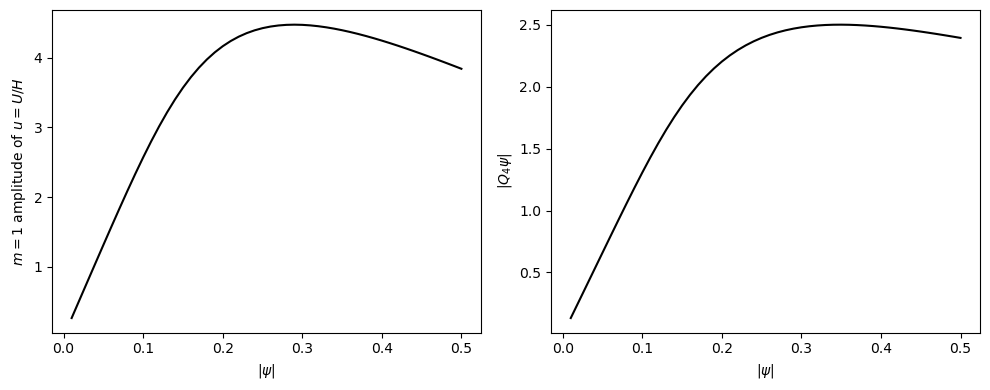

In [53]:
def rhs_simplified(tau, y, alpha, psi):
    """
    Simplified transformed equations.

    y = [U, V, W, H]
    """
    U, V, W, H = y
        
    c = np.cos(tau)
    s = np.sin(tau)

    dU = (
        2.0 * V
        + psi * c 
        - alpha * (psi * s / H + U / H**2)
    )

    dV = (
        -0.5 * U
        + 1.5 * alpha * psi * c / H
        - alpha * V / H**2
    )

    dW = (
        -psi * s * U
        + 1.0 / H
        - H
        - (alpha / 3.0) * (W + psi * c * U) / H**2
        - alpha * (psi**2 * s * c / H + W / H**2)
    )

    dH = W + psi * c * U

    return np.vstack([dU, dV, dW, dH])


def periodic_bc(ya, yb):
    return ya - yb


def initial_guess_simplified(tau, alpha, psi):
    y = np.zeros((4, tau.size))
    y[0] = psi * np.cos(tau)          # U
    y[1] = -0.5 * psi * np.sin(tau)   # V
    y[2] = 0.0                        # W
    y[3] = 1.0                        # H
    return y


def solve_one_simplified(alpha, psi, tau, y_guess=None, tol=1e-8):
    if y_guess is None:
        y_guess = initial_guess_simplified(tau, alpha, psi)

    sol = solve_bvp(
        lambda t, y: rhs_simplified(t, y, alpha, psi),
        periodic_bc,
        tau,
        y_guess,
        tol=tol,
        max_nodes=50000,
        verbose=0,
    )

    if not sol.success:
        print(f"Failed at psi={psi}: {sol.message}")

    return sol


def solve_continuation_simplified(alpha=0.019, psi_values=None, n_grid=600, tol=1e-8):
    if psi_values is None:
        psi_values = np.linspace(0.01, 0.5, 50)

    tau = np.linspace(0.0, 2.0 * np.pi, n_grid)
    sols = []

    y_guess = None
    for psi in psi_values:
        sol = solve_one_simplified(alpha, psi, tau, y_guess=y_guess, tol=tol)
        sols.append(sol)
        y_guess = sol.sol(tau)

    return tau, sols


def m1_amp(tau, y):
    a = np.trapz(y * np.cos(tau), tau) / np.pi
    b = np.trapz(y * np.sin(tau), tau) / np.pi
    return np.sqrt(a*a + b*b)


def calculate_Q4psi_from_UWH(tau, U, W, H, alpha, psi):
    """
    Compute Q4|psi| using original variables:
    u = U/H, w = W/H, g = 1/H^2.
    """
    u = U / H
    w = W / H
    g = 1.0 / H**2

    integrand = np.exp(1j * tau) * (
        u / g * (1.0 + 1j * w)
        - 1j * alpha * (psi * np.sin(tau) + psi * np.cos(tau) * w + u)
    )

    return np.trapz(integrand, tau) / (tau[-1] - tau[0])


# Example
alpha = 0.019
psi_values = np.linspace(0.01, 0.5, 50)

tau_mesh, sols = solve_continuation_simplified(
    alpha=alpha,
    psi_values=psi_values,
    n_grid=600,
    tol=1e-8,
)

tau_plot = np.linspace(0.0, 2.0 * np.pi, 2000, endpoint=False)

U1_list = []
Hmin_list = []
Q4psi_list = []

for psi, sol in zip(psi_values, sols):
    U, V, W, H = sol.sol(tau_plot)

    u = U / H
    v = V / H
    w = W / H
    g = 1.0 / H**2

    U1_list.append(m1_amp(tau_plot, u))
    Hmin_list.append(np.min(H))
    Q4psi_list.append(calculate_Q4psi_from_UWH(tau_plot, U, W, H, alpha, psi))

Q4psi_list = np.array(Q4psi_list)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

axs[0].plot(psi_values, U1_list, "k-")
axs[0].set_xlabel(r"$|\psi|$")
axs[0].set_ylabel(r"$m=1$ amplitude of $u=U/H$")

axs[1].plot(psi_values, np.abs(Q4psi_list), "k-")
axs[1].set_xlabel(r"$|\psi|$")
axs[1].set_ylabel(r"$|Q_4\psi|$")

plt.tight_layout()
plt.show()

## Compare Full, Transformed, and Simplified Equations
We shall see that the three sets of equations give the same result. As it shows below, the simplified model is slightly off but not terrible.

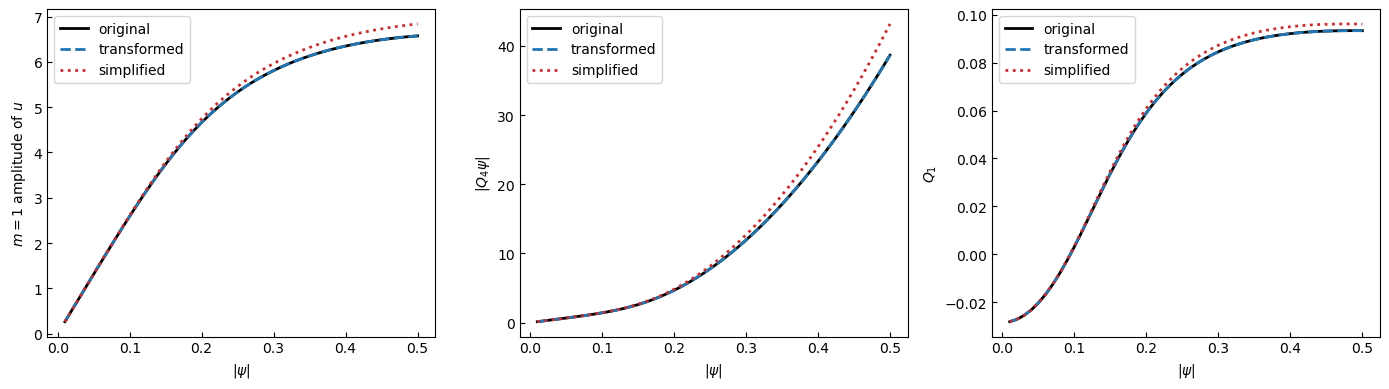

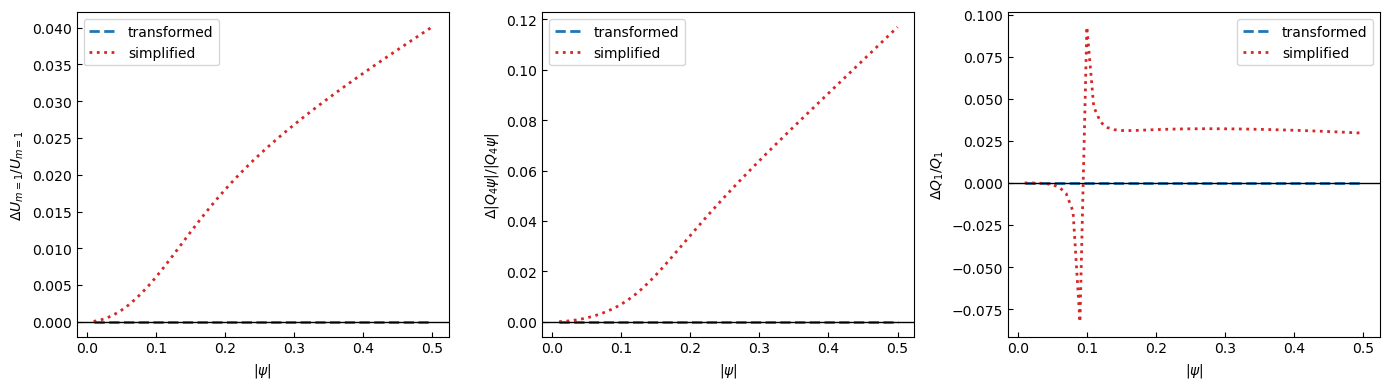

In [30]:
# ------------------------------------------------------------
# Compare rhs, rhs_transformed, and rhs_simplified
# ------------------------------------------------------------

def solve_model(rhs_func, alpha, psi, tau, y_guess, tol=1e-8):
    sol = solve_bvp(
        lambda t, y: rhs_func(t, y, alpha, psi),
        periodic_bc,
        tau,
        y_guess,
        tol=tol,
        max_nodes=50000,
        verbose=0,
    )
    if not sol.success:
        print(f"Failed at psi={psi:.3f}: {sol.message}")
    return sol


def get_original_variables(sol, model_name, tau):
    if model_name == "original":
        u, v, w, g = sol.sol(tau)
    else:
        U, V, W, H = sol.sol(tau)
        u = U / H
        v = V / H
        w = W / H
        g = 1.0 / H**2
    return u, v, w, g


alpha = 0.019
psi_values = np.linspace(0.01, 0.5, 50)

tau_mesh = np.linspace(0.0, 2.0*np.pi, 600)
tau_plot = np.linspace(0.0, 2.0*np.pi, 2000, endpoint=False)

models = {
    "original": {
        "rhs": rhs,
        "guess_func": initial_guess,
        "guess": None,
        "sols": [],
    },
    "transformed": {
        "rhs": rhs_transformed,
        "guess_func": initial_guess_transformed,
        "guess": None,
        "sols": [],
    },
    "simplified": {
        "rhs": rhs_simplified,
        "guess_func": initial_guess_simplified,
        "guess": None,
        "sols": [],
    },
}

# Solve all three models with continuation in psi
for psi in psi_values:
    for name, model in models.items():
        if model["guess"] is None:
            y_guess = model["guess_func"](tau_mesh, alpha, psi)
        else:
            y_guess = model["guess"]

        sol = solve_model(
            model["rhs"],
            alpha,
            psi,
            tau_mesh,
            y_guess,
            tol=1e-8,
        )

        model["sols"].append(sol)
        model["guess"] = sol.sol(tau_mesh)


# Extract diagnostics
diagnostics = {}

for name, model in models.items():
    U1_list = []
    Q1_list = []
    Q4psi_list = []
    gmin_list = []

    for psi, sol in zip(psi_values, model["sols"]):
        u, v, w, g = get_original_variables(sol, name, tau_plot)

        U1_list.append(m1_amp(tau_plot, u))
        Q1_list.append(calculate_Q1(tau_plot, u, v, g, alpha, psi))
        Q4psi_list.append(calculate_Q4psi(tau_plot, u, w, g, alpha, psi))
        gmin_list.append(np.min(g))

    diagnostics[name] = {
        "U1": np.array(U1_list),
        "Q1": np.array(Q1_list),
        "Q4psi": np.array(Q4psi_list),
        "gmin": np.array(gmin_list),
    }


# Plot direct comparison
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

styles = {
    "original": "k-",
    "transformed": "C0--",
    "simplified": "C3:",
}

for name, style in styles.items():
    axs[0].plot(psi_values, diagnostics[name]["U1"], style, lw=2, label=name)
    axs[1].plot(psi_values, np.abs(diagnostics[name]["Q4psi"]), style, lw=2, label=name)
    axs[2].plot(psi_values, diagnostics[name]["Q1"], style, lw=2, label=name)

axs[0].set_ylabel(r"$m=1$ amplitude of $u$")
axs[1].set_ylabel(r"$|Q_4\psi|$")
axs[2].set_ylabel(r"$Q_1$")

for ax in axs:
    ax.set_xlabel(r"$|\psi|$")
    ax.legend()
    ax.tick_params(direction="in", which="both")

plt.tight_layout()
plt.show()


# Plot fractional differences relative to original
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

for name, style in {
    "transformed": "C0--",
    "simplified": "C3:",
}.items():
    axs[0].plot(
        psi_values,
        diagnostics[name]["U1"] / diagnostics["original"]["U1"] - 1.0,
        style,
        lw=2,
        label=name,
    )

    axs[1].plot(
        psi_values,
        np.abs(diagnostics[name]["Q4psi"]) / np.abs(diagnostics["original"]["Q4psi"]) - 1.0,
        style,
        lw=2,
        label=name,
    )

    axs[2].plot(
        psi_values,
        diagnostics[name]["Q1"] / diagnostics["original"]["Q1"] - 1.0,
        style,
        lw=2,
        label=name,
    )

axs[0].set_ylabel(r"$\Delta U_{m=1}/U_{m=1}$")
axs[1].set_ylabel(r"$\Delta |Q_4\psi|/|Q_4\psi|$")
axs[2].set_ylabel(r"$\Delta Q_1/Q_1$")

for ax in axs:
    ax.axhline(0.0, color="k", lw=1)
    ax.set_xlabel(r"$|\psi|$")
    ax.legend()
    ax.tick_params(direction="in", which="both")

plt.tight_layout()
plt.show()

## What drives saturation?

Now the question is what drives saturation? We can test out the answers using the **simplified** equations, but dropping terms in the $U$ equation (one at a time). 
Below are the modified equations of motions.

In [ ]:
def rhs_simplified(tau, y, alpha, psi):
    """
    Simplified transformed equations.

    y = [U, V, W, H]
    """
    U, V, W, H = y
    
    c = np.cos(tau)
    s = np.sin(tau)

    dU = (
        2.0 * V
        + psi * c / H
        - alpha * (psi * s / H + U / H**2)
    )

    dV = (
        -0.5 * U
        + 1.5 * alpha * psi * c / H
        - alpha * V / H**2
    )

    dW = (
        -psi * s * U
        + 1.0 / H
        - H
        - (alpha / 3.0) * (W + psi * c * U) / H**2
        - alpha * (psi**2 * s * c / H + W / H**2)
    )

    dH = W + psi * c * U

    return np.vstack([dU, dV, dW, dH])